description(v3)

__v2からの主な変更__

- 手動CV実装
- 前処理見直し (myload.py)
- StratifiedKFold-CV (by 5-quantiles of target variable)
- EDAは別ファイルへ分離

__リファクタリング__

変数名

- 初期読み込みデータ: train, submit
- 提出用データ: submit_pred
- feature engineering, train_test_split前までのデータ: X, y
- train_test_split後のデータ: X_train, X_test, y_train, y_test (サフィックスがフル表記)
- CVのカレントホールドの学習データ: x_tr, y_tr (小文字 ＆ サフィックスが省略表記)
- CVのカレントホールドの検証データ: x_va, y_va (小文字 ＆ サフィックスが省略表記)

In [1]:
# first import
import warnings
from importlib import reload

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from polars import selectors as cs

%matplotlib inline

warnings.filterwarnings('ignore')
from module import myload

reload(myload)
from module.myload import load_data

print("first import completed")

train, submit = load_data()
print("data load completed")
print(f"train: {train.shape}")
print(f"submit : {submit.shape}")
print(f"diff col : {set(train.columns) - set(submit.columns)}")

first import completed
data load completed
train: (1458, 81)
submit : (1459, 79)
diff col : {'price_bin', 'SalePrice'}


In [2]:
# feature engineering

X = train.copy()
y = X.pop("SalePrice")
bins = X.pop("price_bin")

# tempolary,evaluate only select numeric columns as feature engineering
X = pl.DataFrame(X).select(cs.numeric()).to_pandas()

X.shape

(1458, 33)

In [3]:
# base models definition

from lightgbm import LGBMRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.pipeline import FunctionTransformer, make_pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor

models = {}
models["enet"] = make_pipeline(
    RobustScaler(),
    ElasticNet(alpha=0.001,l1_ratio=0.5,random_state=711))
models["lasso"] = make_pipeline(
    RobustScaler(),
    Lasso(alpha=0.001,random_state=711))
models["xgb"] = XGBRegressor(
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=1,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=711,
    n_jobs=-1,
)
models["lgbm"] = LGBMRegressor(
    objective="regression",
    learning_rate=0.05,
    reg_alpha=0.01,
    reg_lambda=10,
    max_depth=6,
    num_leaves=16,
    colsample_bytree=0.7,
    subsample=0.7,
    min_child_samples=1,
    verbosity=-1
)

print(f"defined base models : {models.keys()}")

defined base models : dict_keys(['enet', 'lasso', 'xgb', 'lgbm'])


In [4]:
# implement target log transformer to base models 

log_transformer = FunctionTransformer(
    np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
    feature_names_out="one-to-one",
)

models = {
    name: TransformedTargetRegressor(
        regressor=model,
        transformer=log_transformer,
        check_inverse=False,
    )
    for name, model in models.items()
}

print(f"base models were built with target transformer : {models.keys()}")

base models were built with target transformer : dict_keys(['enet', 'lasso', 'xgb', 'lgbm'])


In [5]:
# valid preparation (train_test_split)

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid, bin_train, _ = train_test_split(X,y,bins,test_size=0.2,random_state=711,stratify=bins)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)
y_train.name += "_train"
y_valid.name += "_valid"

# sns.histplot([y_train,y_valid],multiple="dodge")

(1166, 33) (292, 33) (1166,) (292,)


In [33]:
# stratified 5-fold cross validation

from sklearn.base import clone
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import StratifiedKFold

folds = 5
skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=711)
cv_score = []

for name, model in models.items():
    
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, bin_train)):
        # split cv dataset
        x_tr,x_va = X_train.iloc[tr_idx],X_train.iloc[va_idx]
        y_tr,y_va = y_train.iloc[tr_idx],y_train.iloc[va_idx]
        
        # fit and predict
        fold_model = clone(model)
        fold_model.fit(x_tr,y_tr)
        tr_pred = fold_model.predict(x_tr)
        va_pred = fold_model.predict(x_va)
                
        # register
        cv_score.append({
            "fold": fold,
            "model":name,
            "tr": root_mean_squared_log_error(y_tr, tr_pred),
            "va": root_mean_squared_log_error(y_va, va_pred)
            })
        
# show score
cv_score_df = pd.DataFrame(cv_score)
cv_score_df["gap"] = cv_score_df["va"] - cv_score_df["tr"]
cv_score_df.groupby("model")[["tr", "va", "gap"]].agg(["mean", "std"])


tr                  va                 gap          
           mean       std      mean       std      mean       std
model                                                            
enet   0.119883  0.001028  0.125534  0.004617  0.005652  0.005632
lasso  0.120070  0.001030  0.125617  0.004669  0.005547  0.005678
lgbm   0.085539  0.000907  0.133777  0.004062  0.048238  0.004041
xgb    0.062949  0.001697  0.128011  0.006117  0.065063  0.007529

<Axes: xlabel='model', ylabel='rmsle'>

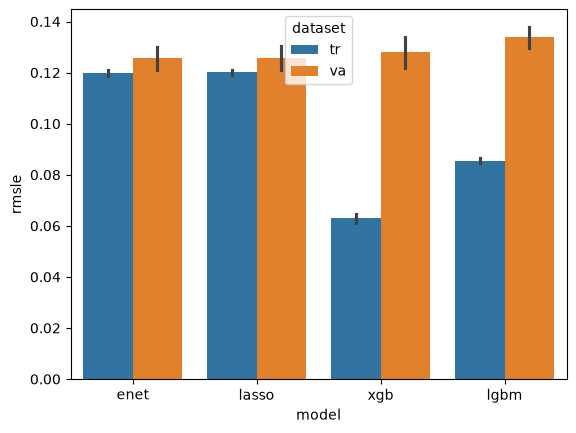

In [ ]:
# plot cv score

plot_df = cv_score_df.melt(
        id_vars="model",
        value_vars=["tr", "va"],
        var_name="dataset",
        value_name="rmsle",
    )

sns.barplot(data=plot_df,x="model",y="rmsle",hue="dataset",errorbar="sd",)